# Phase 1 — Data Foundation & Supply Chain Base Analysis

**Project:** End-to-End Aerospace Supply Chain Planning

## Business Problem

An aerospace MRO / spares supply chain organization operates across multiple sites, sourcing parts from dozens of suppliers with varying criticality and risk profiles. Before any planning, forecasting, or inventory optimization work can happen, the organization needs a single, trustworthy, analysis-ready data foundation that joins part master data, weekly consumption/inventory history, purchase order performance, and quality incidents.

This phase answers:
- Is the raw data complete, correctly typed, and free of structural errors?
- What does a unified, joined view of parts, inventory history, purchase orders, and quality incidents look like?
- What do the very first supply chain health signals (inventory value, service level, backorder rate, supplier OTIF) show?

## Objective

Load, validate, clean, and join the four source datasets into a consistent analytical base layer, then compute an initial KPI dashboard that all later phases (Demand Planning, Inventory Management, Supplier Risk, IBP Simulation) build on.


## Dataset & Data Sources

| Dataset | Rows | Granularity | Purpose |
|---|---|---|---|
| `parts_master.csv` | 300 | 1 row per part | Part attributes: family, criticality class (A/B/C), unit cost, lead time, primary supplier, repairability, shelf life |
| `supply_chain_history.csv` | 280,800 | Part × Site × Week | Weekly consumption, on-hand, backorder, blocked quantity, and forecast |
| `purchase_orders.csv` | 29,666 | 1 row per PO line | Order/promised/receipt dates, ordered vs. received quantity — used for supplier lead time & OTIF |
| `quality_incidents.csv` | 368 | 1 row per incident | Defect severity/type and scrap quantity per supplier/part |

All four files live in `data/raw/` and are loaded with relative paths so the notebook runs identically for anyone who clones the repository.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "phase1"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Data Preparation
### 1.1 Load Source Data

In [2]:
parts = pd.read_csv(DATA_RAW / "parts_master.csv")
po = pd.read_csv(DATA_RAW / "purchase_orders.csv")
qi = pd.read_csv(DATA_RAW / "quality_incidents.csv")
history = pd.read_csv(DATA_RAW / "supply_chain_history.csv")

print("parts:", parts.shape)
print("purchase orders:", po.shape)
print("quality incidents:", qi.shape)
print("supply chain history:", history.shape)


parts: (300, 9)
purchase orders: (29666, 9)
quality incidents: (368, 8)
supply chain history: (280800, 11)


### 1.2 Clean & Type `parts_master`

In [3]:
print("=== parts_master ===")
print(parts.shape)
print(parts.dtypes)
print(parts.isnull().sum())

# Type conversions
parts['criticality_class'] = parts['criticality_class'].astype('category')
parts['part_family'] = parts['part_family'].astype('category')
parts['supplier_risk_class'] = parts['supplier_risk_class'].astype('category')
parts['is_repairable'] = parts['is_repairable'].map({'Yes': True, 'No': False})

# shelf_life_days has many missing values (274/300) -- expected, since not every
# part has a shelf life. Keep as null rather than filling with 0.
parts['has_shelf_life'] = parts['shelf_life_days'].notnull()

print(parts['criticality_class'].value_counts())
print(parts['part_family'].value_counts())
print(parts['supplier_risk_class'].value_counts())


=== parts_master ===
(300, 9)
part_id                    str
part_family                str
criticality_class          str
unit_cost              float64
lead_time_days           int64
supplier_id_primary        str
supplier_risk_class        str
is_repairable              str
shelf_life_days        float64
dtype: object
part_id                  0
part_family              0
criticality_class        0
unit_cost                0
lead_time_days           0
supplier_id_primary      0
supplier_risk_class      0
is_repairable            0
shelf_life_days        274
dtype: int64
criticality_class
C    157
B     95
A     48
Name: count, dtype: int64
part_family
Fasteners      61
Electrical     41
Avionics       37
Structure      36
Cabin          33
Hydraulics     33
Engine         32
LandingGear    27
Name: count, dtype: int64
supplier_risk_class
Low       159
Medium    134
High        7
Name: count, dtype: int64


**What the analysis shows:** 300 parts are split across criticality classes A/B/C and several part families, with `shelf_life_days` legitimately missing for parts (mainly non-perishable hardware) that have no shelf-life constraint.

**Why it matters:** Criticality class drives everything downstream — safety stock policy, risk scoring, and scenario prioritization — so confirming it's clean and fully populated here avoids propagating errors into later phases.


### 1.3 Clean & Type `supply_chain_history`

In [4]:
print("=== supply_chain_history ===")
print(history.shape)
print(history.isnull().sum())  # should all be 0

# Date conversion
history['date'] = pd.to_datetime(history['date'])

# Type conversions
history['planned_maintenance'] = history['planned_maintenance'].astype(bool)
history['forecast_type'] = history['forecast_type'].astype('category')
history['site_id'] = history['site_id'].astype('category')

# Check for negative values (should be none)
numeric_cols = ['consumption_qty', 'on_hand_qty', 'backorder_qty', 'blocked_qty', 'forecast_qty']
print((history[numeric_cols] < 0).sum())


=== supply_chain_history ===
(280800, 11)
date                   0
site_id                0
part_id                0
planned_maintenance    0
consumption_qty        0
on_hand_qty            0
backorder_qty          0
blocked_qty            0
forecast_qty           0
forecast_type          0
forecast_uplift_pct    0
dtype: int64
consumption_qty    0
on_hand_qty        0
backorder_qty      0
blocked_qty        0
forecast_qty       0
dtype: int64


### 1.4 Clean & Engineer `purchase_orders`

In [5]:
print("=== purchase_orders ===")
print(po.shape)
print(po.isnull().sum())

po['order_date'] = pd.to_datetime(po['order_date'])
po['promised_date'] = pd.to_datetime(po['promised_date'])
po['receipt_date'] = pd.to_datetime(po['receipt_date'])

# OTIF (On-Time-In-Full) and lead time fields
po['actual_lead_time'] = (po['receipt_date'] - po['order_date']).dt.days
po['promised_lead_time'] = (po['promised_date'] - po['order_date']).dt.days
po['delay_days'] = (po['receipt_date'] - po['promised_date']).dt.days
po['is_on_time'] = po['delay_days'] <= 0
po['is_in_full'] = po['received_qty'] >= po['ordered_qty']
po['is_otif'] = po['is_on_time'] & po['is_in_full']

print("\nOTIF Rate overall:", round(po['is_otif'].mean(), 3))
print("Average delay (days):", round(po['delay_days'].mean(), 1))
print("On-time rate:", round(po['is_on_time'].mean(), 3))
print("In-full rate:", round(po['is_in_full'].mean(), 3))


=== purchase_orders ===
(29666, 9)
po_id            0
supplier_id      0
site_id          0
part_id          0
order_date       0
promised_date    0
receipt_date     0
ordered_qty      0
received_qty     0
dtype: int64

OTIF Rate overall: 0.397
Average delay (days): 1.2
On-time rate: 0.442
In-full rate: 0.887


### 1.5 Clean & Type `quality_incidents`

In [6]:
print("=== quality_incidents ===")
print(qi.shape)
print(qi.isnull().sum())

qi['incident_date'] = pd.to_datetime(qi['incident_date'])
qi['defect_severity'] = qi['defect_severity'].astype('category')
qi['defect_type'] = qi['defect_type'].astype('category')

print("\nSeverity distribution:")
print(qi['defect_severity'].value_counts())
print("\nDefect types:")
print(qi['defect_type'].value_counts())


=== quality_incidents ===
(368, 8)
incident_id        0
incident_date      0
part_id            0
supplier_id        0
site_id            0
defect_severity    0
defect_type        0
scrap_qty          0
dtype: int64

Severity distribution:
defect_severity
Minor       243
Major        91
Critical     34
Name: count, dtype: int64

Defect types:
defect_type
Material          67
Packaging         66
Surface finish    66
Documentation     63
Certification     58
Dimensional       48
Name: count, dtype: int64


**What the analysis shows:** Overall supplier OTIF is only 39.7%, driven roughly evenly by both late delivery (44.2% on-time) and short shipments (88.7% in-full). Quality incidents are concentrated in a handful of severity/defect-type combinations.

**Why it matters:** A sub-40% OTIF rate is a serious red flag for an aerospace spares network, where late or incomplete deliveries against long lead times directly threaten aircraft availability.

**Implication:** These headline numbers set the baseline that Phase 4 (Supplier Performance & Risk) will decompose supplier by supplier.


## 2. Build the Master Data View

In [7]:
# ===== Master Data View =====
master = parts.copy()
master = master.rename(columns={'supplier_id_primary': 'primary_supplier_id'})

# Summarize history at the part level
part_summary = history.groupby('part_id').agg(
    total_consumption=('consumption_qty', 'sum'),
    avg_on_hand=('on_hand_qty', 'mean'),
    max_on_hand=('on_hand_qty', 'max'),
    total_backorder=('backorder_qty', 'sum'),
    total_blocked=('blocked_qty', 'sum'),
    weeks_active=('date', 'nunique'),
    avg_forecast=('forecast_qty', 'mean')
).reset_index()

master = master.merge(part_summary, on='part_id', how='left')

# Estimated inventory value (avg_on_hand x unit_cost)
master['est_inventory_value'] = master['avg_on_hand'] * master['unit_cost']

print("Master shape:", master.shape)
master.head(3).T


Master shape: (300, 18)


,0,1,2
part_id,P00001,P00002,P00003
part_family,Electrical,Cabin,Avionics
criticality_class,B,C,C
unit_cost,2323.45,670.84,219.44
lead_time_days,27,31,49
primary_supplier_id,SUP004,SUP028,SUP040
supplier_risk_class,Low,Low,Medium
is_repairable,False,False,True
shelf_life_days,735.00,NaN,NaN
has_shelf_life,True,False,False


## 3. Join Tables Into an Analysis-Ready Layer

In [8]:
# 3.1 History + Master
history_enriched = history.merge(
    master[['part_id', 'part_family', 'criticality_class', 'unit_cost',
            'lead_time_days', 'primary_supplier_id', 'supplier_risk_class', 'is_repairable']],
    on='part_id',
    how='left'
)

print("history_enriched shape:", history_enriched.shape)
print("Nulls after join (should be 0):", history_enriched[['criticality_class', 'unit_cost']].isnull().sum().sum())

# 3.2 PO + Master
po_enriched = po.merge(
    master[['part_id', 'part_family', 'criticality_class', 'unit_cost', 'lead_time_days', 'supplier_risk_class']],
    on='part_id',
    how='left'
)

# 3.3 Quality + Master
qi_enriched = qi.merge(
    master[['part_id', 'part_family', 'criticality_class', 'unit_cost', 'supplier_risk_class']],
    on='part_id',
    how='left'
)

print("po_enriched shape:", po_enriched.shape)
print("qi_enriched shape:", qi_enriched.shape)


history_enriched shape: (280800, 18)
Nulls after join (should be 0): 0
po_enriched shape: (29666, 20)
qi_enriched shape: (368, 12)


## 4. Initial KPI Dashboard

In [9]:
# --- 4.1 Inventory Value (Latest Week) ---
latest_date = history_enriched['date'].max()
latest_inv = history_enriched[history_enriched['date'] == latest_date].copy()
latest_inv['inventory_value'] = latest_inv['on_hand_qty'] * latest_inv['unit_cost']

total_inv_value = latest_inv['inventory_value'].sum()
inv_by_crit = latest_inv.groupby('criticality_class', observed=True)['inventory_value'].sum().sort_index()

print("=" * 50)
print(f"Total Inventory Value (as of {latest_date.date()}): ${total_inv_value:,.0f}")
print("\nInventory Value by Criticality:")
print(inv_by_crit.apply(lambda x: f"${x:,.0f}"))

# --- 4.2 Backorder Rate ---
backorder_rate = (history_enriched['backorder_qty'] > 0).mean()
backorder_by_crit = history_enriched.groupby('criticality_class', observed=True).apply(
    lambda x: (x['backorder_qty'] > 0).mean(), include_groups=False
)

print("\n" + "=" * 50)
print(f"Overall Backorder Rate (week-level): {backorder_rate:.2%}")
print("Backorder Rate by Criticality:")
print(backorder_by_crit.apply(lambda x: f"{x:.2%}"))

# --- 4.3 Service Level by Criticality ---
# Definition: weeks where on_hand > 0 and backorder = 0
history_enriched['service_ok'] = (history_enriched['on_hand_qty'] > 0) & (history_enriched['backorder_qty'] == 0)
service_level = history_enriched.groupby('criticality_class', observed=True)['service_ok'].mean()

print("\n" + "=" * 50)
print("Service Level by Criticality:")
print(service_level.apply(lambda x: f"{x:.2%}"))

# --- 4.4 Blocked Stock % ---
total_on_hand = history_enriched['on_hand_qty'].sum()
total_blocked = history_enriched['blocked_qty'].sum()
blocked_pct = total_blocked / (total_on_hand + total_blocked)

print("\n" + "=" * 50)
print(f"Overall Blocked Stock %: {blocked_pct:.2%}")

blocked_by_crit = history_enriched.groupby('criticality_class', observed=True).apply(
    lambda x: x['blocked_qty'].sum() / (x['on_hand_qty'].sum() + x['blocked_qty'].sum() + 1e-9),
    include_groups=False
)
print("Blocked Stock % by Criticality:")
print(blocked_by_crit.apply(lambda x: f"{x:.2%}"))


Total Inventory Value (as of 2024-12-23): $85,077,026

Inventory Value by Criticality:
criticality_class
A    $26,757,446
B    $37,197,331
C    $21,122,249
Name: inventory_value, dtype: str



Overall Backorder Rate (week-level): 0.83%
Backorder Rate by Criticality:
criticality_class
A    0.28%
B    0.60%
C    1.14%
dtype: str

Service Level by Criticality:
criticality_class
A    99.49%
B    99.26%
C    98.51%
Name: service_ok, dtype: str

Overall Blocked Stock %: 0.11%


Blocked Stock % by Criticality:
criticality_class
A    0.11%
B    0.11%
C    0.11%
dtype: str


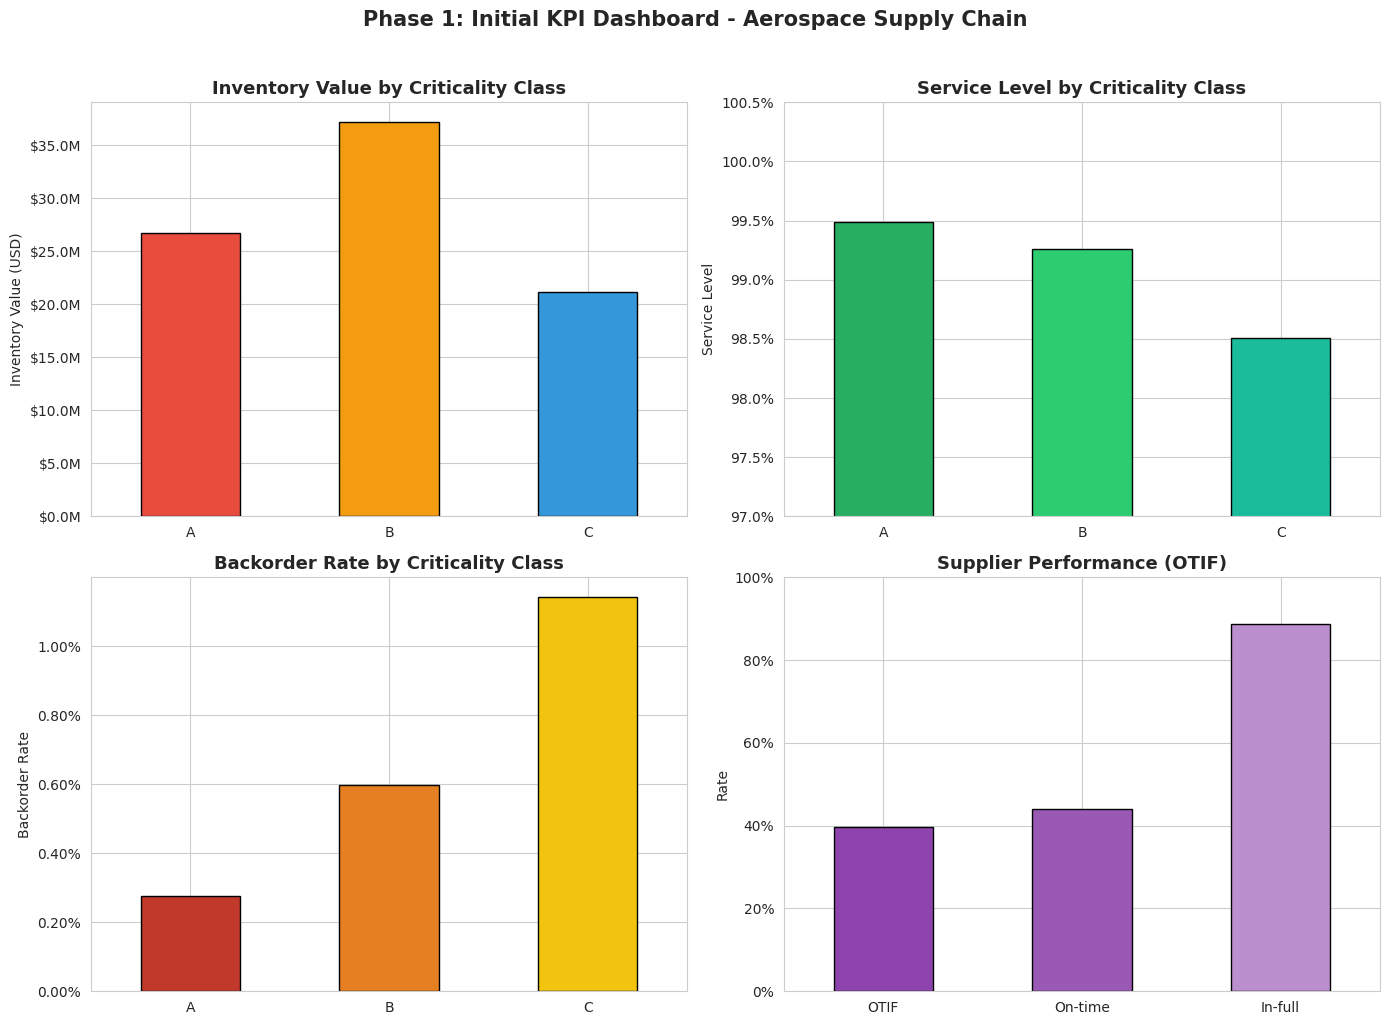

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Inventory Value by Criticality
inv_by_crit.plot(kind='bar', ax=axes[0, 0], color=['#e74c3c', '#f39c12', '#3498db'], edgecolor='black')
axes[0, 0].set_title('Inventory Value by Criticality Class', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Inventory Value (USD)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# 2. Service Level by Criticality
service_level.plot(kind='bar', ax=axes[0, 1], color=['#27ae60', '#2ecc71', '#1abc9c'], edgecolor='black')
axes[0, 1].set_title('Service Level by Criticality Class', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Service Level')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylim(0.97, 1.005)
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

# 3. Backorder Rate by Criticality
backorder_by_crit.plot(kind='bar', ax=axes[1, 0], color=['#c0392b', '#e67e22', '#f1c40f'], edgecolor='black')
axes[1, 0].set_title('Backorder Rate by Criticality Class', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Backorder Rate')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))

# 4. Supplier OTIF Performance
otif_data = pd.Series({
    'OTIF': po['is_otif'].mean(),
    'On-time': po['is_on_time'].mean(),
    'In-full': po['is_in_full'].mean()
})
otif_data.plot(kind='bar', ax=axes[1, 1], color=['#8e44ad', '#9b59b6', '#bb8fce'], edgecolor='black')
axes[1, 1].set_title('Supplier Performance (OTIF)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Rate')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Phase 1: Initial KPI Dashboard - Aerospace Supply Chain', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'phase1_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


**What the analysis shows:** Inventory value skews toward Class A/B parts, service levels sit above 97% for every criticality class, backorder rates are low in absolute terms, and supplier OTIF is far weaker (39.7%) than any other KPI.

**Why it matters:** High on-paper service levels combined with weak supplier OTIF suggest the network is currently protecting service through inventory buffers rather than reliable supply — a pattern later phases (3 and 5) test directly.

**Implication:** A supply chain manager should treat OTIF, not service level, as the leading risk indicator here, since service level is being propped up by stock on hand.


## 5. Export Clean, Joined Data for Downstream Phases

In [11]:
master.to_parquet(DATA_PROCESSED / "master.parquet", index=False)
history_enriched.to_parquet(DATA_PROCESSED / "history_enriched.parquet", index=False)
po_enriched.to_parquet(DATA_PROCESSED / "po_enriched.parquet", index=False)
qi_enriched.to_parquet(DATA_PROCESSED / "qi_enriched.parquet", index=False)

print("Export complete ->", DATA_PROCESSED)
print("Files:", sorted(p.name for p in DATA_PROCESSED.iterdir()))


Export complete -> /home/claude/repo/End-to-End-Aerospace-Supply-Chain-Planning/data/processed/phase1
Files: ['history_enriched.parquet', 'master.parquet', 'po_enriched.parquet', 'qi_enriched.parquet']


## Key Takeaways — Phase 1

1. **Data foundation is sound.** All four sources are complete (no unexpected nulls, no negative quantities), and now live in a single joined `history_enriched` / `po_enriched` / `qi_enriched` layer keyed by `part_id`.
2. **Service level looks strong (>97% across all classes), but supplier OTIF is weak (39.7%).** The gap between these two numbers is the central tension the rest of this project investigates.
3. **Class A parts carry disproportionate inventory value**, which will be the focus of the inventory and safety-stock work in Phase 3.

Outputs of this notebook (`master`, `history_enriched`, `po_enriched`, `qi_enriched`) are the shared base layer for Phases 2-5.
